# 🔩 Hard Drive Failure Prediction System
### Production-Grade Predictive Maintenance — Backblaze SMART Data

---

## Architecture
```
seagate_cleaned_cols.csv  ← entry point
    → DataLoader → Preprocessor → FeatureEngineer → Splitter
    → BaseModels (LightGBM bags + XGBoost + CatBoost)
    → StackingEnsemble (meta-LightGBM, leak-free OOF)
    → Evaluator (row-level + drive-level)
    → EarlyWarningSystem
    → InferencePipeline (saved to artifacts/)
```

## Key Design Decisions
| Decision | Reason |
|---|---|
| Polars for all data work | 3× less RAM than pandas on 10M rows |
| Pandas only for model training | sklearn/lgbm require numpy arrays |
| Time-ordered OOF stacking | Random k-fold leaks future data into meta-model |
| Right-censoring the last 14 days | Labels incomplete at dataset boundary |
| Drive-level downsampling | Preserves drive history, reduces class imbalance |
| UnderBagging (5 LGBM models) | Better than single model on extreme imbalance |
| PR-AUC as primary metric | ROC-AUC is misleading on highly imbalanced data |

## ⚙️ Setup — Install Dependencies

In [1]:
# Install any missing dependencies
# !pip install polars lightgbm xgboost catboost shap scikit-learn matplotlib seaborn joblib
import sys, importlib
for pkg in ["polars", "lightgbm", "xgboost", "shap", "sklearn", "joblib"]:
    try:
        importlib.import_module(pkg)
        print(f"✅ {pkg}")
    except ImportError:
        print(f"❌ {pkg} — install with: pip install {pkg}")

✅ polars
✅ lightgbm
✅ xgboost
✅ shap
✅ sklearn
✅ joblib


## 📦 Import the Production System

In [2]:
# ── The entire system lives in drive_failure_system.py ──
from drive_failure_system import (
    PipelineConfig,
    DriveFailurePipeline,
    InferencePipeline,
    EarlyWarningSystem,
)
import polars as pl
import pandas as pd

print("✅ System imported successfully")

✅ System imported successfully


e:\WE Work\Abdalrhman\ML\New folder\drive_failure_system.py:57: UserWarning: CatBoost not installed — skipping CatBoost model.
  warnings.warn("CatBoost not installed — skipping CatBoost model.")


## 🔧 Configuration — All Knobs in One Place

In [3]:
import datetime

cfg = PipelineConfig(
    # ── Paths ─────────────────────────────────────────────────────────────
    cleaned_csv   = "seagate_cleaned_cols.csv",  # ← only required input file
    artifacts_dir = "artifacts",

    # ── Target ────────────────────────────────────────────────────────────
    prediction_horizon = 14,      # predict failures within 14 days

    # ── Drive downsampling ────────────────────────────────────────────────
    healthy_drive_multiplier = 3, # 3 healthy drives per failed drive

    # ── Feature engineering ───────────────────────────────────────────────
    rolling_windows = [7, 14, 30],
    lag_days        = [1, 3, 7],

    # ── Time split ────────────────────────────────────────────────────────
    val_start  = datetime.date(2025, 11, 16),
    test_start = datetime.date(2025, 12,  1),
    end_date   = datetime.date(2025, 12, 17),  # right-censor boundary

    # ── Models ────────────────────────────────────────────────────────────
    n_lgbm_bags     = 5,
    desired_neg_ratio = 20,
    n_meta_folds    = 5,   # OOF folds for stacking

    # ── Threshold ─────────────────────────────────────────────────────────
    recall_target = 0.85,  # minimum recall we want

    # ── Early warning ─────────────────────────────────────────────────────
    alert_threshold        = 0.60,
    alert_consecutive_days = 2,

    seed = 42,
)

print("✅ Config ready")
print(f"   Prediction horizon : {cfg.prediction_horizon} days")
print(f"   Rolling windows    : {cfg.rolling_windows}")
print(f"   Lag days           : {cfg.lag_days}")
print(f"   Val start          : {cfg.val_start}")
print(f"   Test start         : {cfg.test_start}")

✅ Config ready
   Prediction horizon : 14 days
   Rolling windows    : [7, 14, 30]
   Lag days           : [1, 3, 7]
   Val start          : 2025-11-16
   Test start         : 2025-12-01


## 🚀 Run the Full Pipeline

Set `rebuild_csv=True` on the first run (or when new data arrives).  
Set `rebuild_csv=False` on subsequent runs to skip the slow CSV merge step.

2026-04-26 18:51:59 | INFO     | DriveFailure | =================================================================
2026-04-26 18:51:59 | INFO     | DriveFailure |   DRIVE FAILURE PREDICTION PIPELINE  —  START
2026-04-26 18:51:59 | INFO     | DriveFailure |   Input file: seagate_cleaned_cols.csv
2026-04-26 18:51:59 | INFO     | DriveFailure | =================================================================
e:\WE Work\Abdalrhman\ML\New folder\drive_failure_system.py:236: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  smart_cols = [c for c in lf.columns if c.startswith("smart_")]
2026-04-26 18:52:32 | INFO     | DriveFailure | Loaded: 10,313,997 rows × 63 cols  |  2798 MB
2026-04-26 18:52:34 | INFO     | DriveFailure | After removing post-failure rows: 10,313,997 rows
2026-04-26 18:52:35 | INFO     | DriveFailu

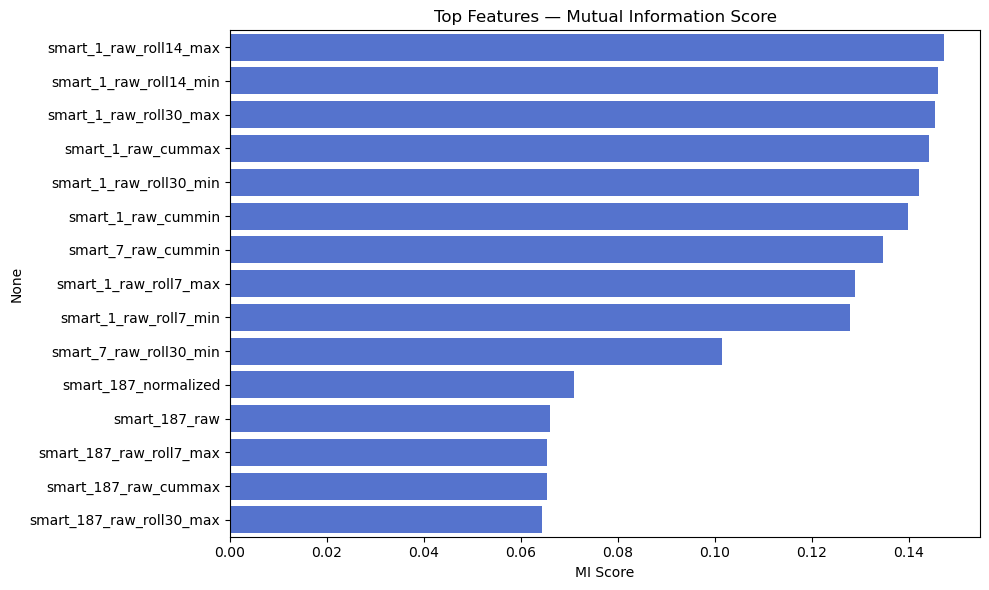

2026-04-26 18:54:50 | INFO     | DriveFailure | X_train: (66891, 35)  |  X_val: (19561, 35)  |  X_test: (20027, 35)
2026-04-26 18:54:50 | INFO     | DriveFailure | Training LightGBM UnderBagging (5 bags)...


[LightGBM] [Info] Number of positive: 3363, number of negative: 63528
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009979 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8520
[LightGBM] [Info] Number of data points in the train set: 66891, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050276 -> initscore=-2.938647
[LightGBM] [Info] Start training from score -2.938647


2026-04-26 18:54:54 | INFO     | DriveFailure |   Bag 1/5 done


[LightGBM] [Info] Number of positive: 3363, number of negative: 63528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8520
[LightGBM] [Info] Number of data points in the train set: 66891, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050276 -> initscore=-2.938647
[LightGBM] [Info] Start training from score -2.938647


2026-04-26 18:54:57 | INFO     | DriveFailure |   Bag 2/5 done


...

2026-04-26 18:56:15 | INFO     | DriveFailure |   Bag 5/5 done
2026-04-26 18:56:15 | INFO     | DriveFailure | Training XGBoost...


[0]	validation_0-aucpr:0.16775
[128]	validation_0-aucpr:0.24547


2026-04-26 18:56:18 | INFO     | DriveFailure | XGBoost done
2026-04-26 18:56:18 | WARNING  | DriveFailure | CatBoost not installed — skipping.
2026-04-26 18:56:19 | INFO     | DriveFailure |   OOF fold 4/4 done
2026-04-26 18:56:20 | INFO     | DriveFailure | Training meta-LightGBM on OOF meta-features...


[LightGBM] [Info] Number of positive: 2568, number of negative: 50944
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 53512, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.047989 -> initscore=-2.987600
[LightGBM] [Info] Start training from score -2.987600
[50]	valid_0's binary_logloss: 0.112903


2026-04-26 18:56:20 | INFO     | DriveFailure | Meta-model training complete ✅
2026-04-26 18:56:22 | INFO     | DriveFailure | 
2026-04-26 18:56:22 | INFO     | DriveFailure |   LightGBM (bags) — Row-Level Evaluation
2026-04-26 18:56:22 | INFO     | DriveFailure | =======================================================
2026-04-26 18:56:22 | INFO     | DriveFailure |   ROC-AUC   : 0.8711
2026-04-26 18:56:22 | INFO     | DriveFailure |   PR-AUC    : 0.5151   ← PRIMARY METRIC
2026-04-26 18:56:22 | INFO     | DriveFailure |   Threshold : 0.0125
2026-04-26 18:56:22 | INFO     | DriveFailure |   Recall    : 0.8568
2026-04-26 18:56:22 | INFO     | DriveFailure |   Precision : 0.0765
2026-04-26 18:56:22 | INFO     | DriveFailure |   F1        : 0.1404
2026-04-26 18:56:22 | INFO     | DriveFailure |   Confusion : TN=14,556  FP=4,989  FN=69  TP=413
2026-04-26 18:56:22 | INFO     | DriveFailure | =======================================================

2026-04-26 18:56:22 | INFO     | DriveFailur

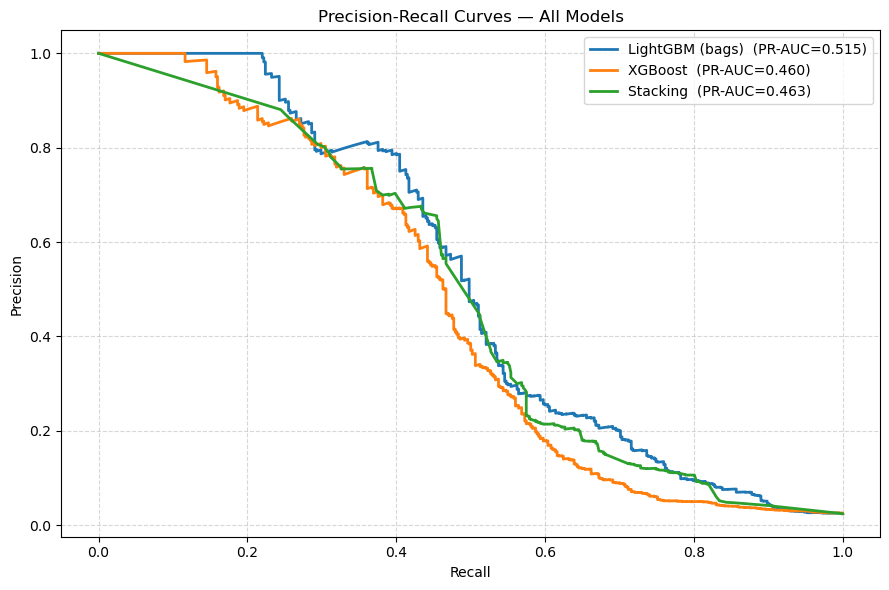

2026-04-26 18:56:23 | INFO     | DriveFailure | 
Threshold Sweep (Stacking Ensemble):
 threshold  TP  FP  FN  recall  precision
      0.30 267 561 215   0.554      0.322
      0.35 262 488 220   0.544      0.349
      0.40 211 108 271   0.438      0.661
      0.45 205  99 277   0.425      0.674
      0.50 188  80 294   0.390      0.701
      0.55 173  56 309   0.359      0.755
      0.60 157  51 325   0.326      0.755
      0.65 146  36 336   0.303      0.802
      0.70 121  18 361   0.251      0.871
      0.75   0   0 482   0.000      0.000
      0.80   0   0 482   0.000      0.000
      0.85   0   0 482   0.000      0.000
      0.90   0   0 482   0.000      0.000
      0.95   0   0 482   0.000      0.000


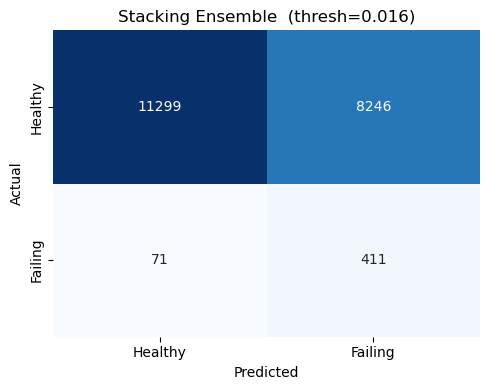

2026-04-26 18:56:23 | INFO     | DriveFailure | Computing SHAP on 1000-row sample...
c:\Users\INTEGRA\anaconda3\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


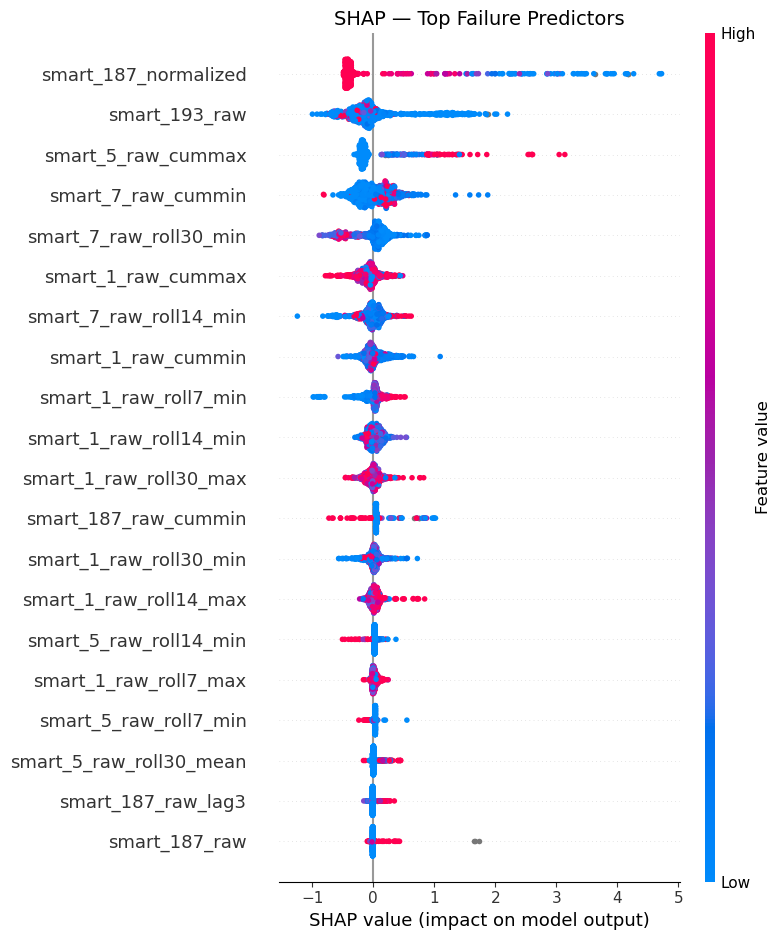

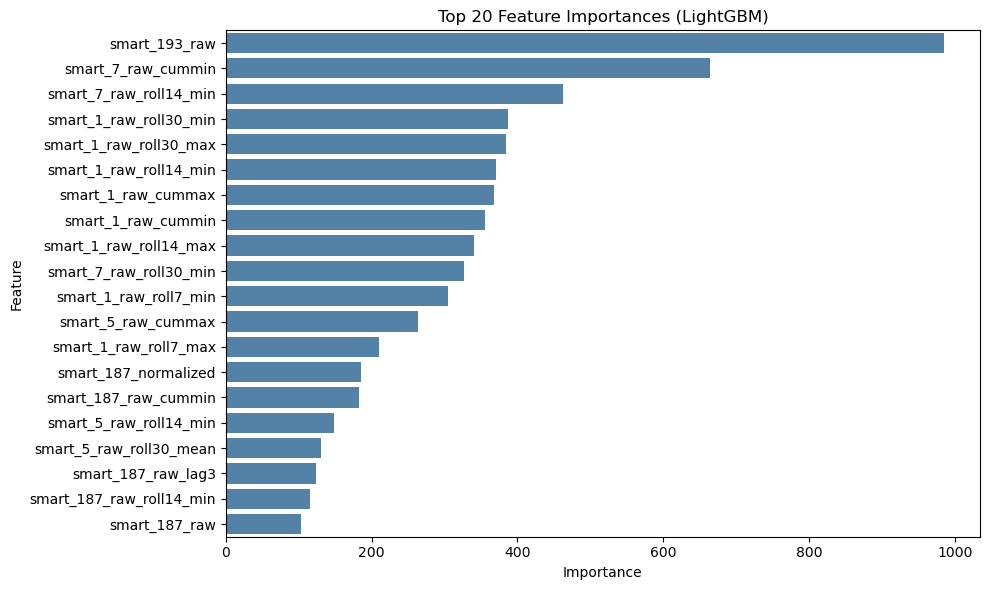

2026-04-26 18:56:28 | INFO     | DriveFailure | Pipeline saved → artifacts\inference_pipeline.joblib
2026-04-26 18:56:28 | INFO     | DriveFailure | 
✅  Pipeline complete in 4.5 minutes
2026-04-26 18:56:28 | INFO     | DriveFailure |     Artifacts saved in: artifacts/


In [4]:
pipeline = DriveFailurePipeline(cfg)
pipeline.run()  # reads directly from seagate_cleaned_cols.csv

---
## 🔮 Inference on New Data

Once the pipeline has been trained and saved, you can score new SMART data
with just 3 lines of code — no need to retrain.

The inference pipeline applies the exact same feature transformations
automatically before passing data to the stacking ensemble.

In [5]:
# ── Load the saved pipeline ───────────────────────────────────────────────
inference = InferencePipeline.load("artifacts/inference_pipeline.joblib")

# ── Score new daily data ──────────────────────────────────────────────────
# new_data = pl.read_csv("new_daily_smart_data.csv")  # your new data here
# scored   = inference.score(new_data)

# ── OR: use the already-trained pipeline directly ─────────────────────────
# scored = pipeline.inference.score(new_data)

# ── View results ──────────────────────────────────────────────────────────
# print(scored[["serial_number", "date", "failure_prob", "alert"]].head(20))

print("Inference pipeline ready.")
print("Usage: scored = inference.score(new_data_polars_df)")

2026-04-26 18:56:29 | INFO     | DriveFailure | Pipeline loaded from artifacts/inference_pipeline.joblib


Inference pipeline ready.
Usage: scored = inference.score(new_data_polars_df)


## 🚨 Early Warning System

The Early Warning System (EWS) filters noisy single-day spikes.  
A maintenance alert is raised only when a drive exceeds the probability threshold  
for **N consecutive days** (configurable via `alert_consecutive_days`).

Typical business setting: threshold=0.60, consecutive_days=2 → good precision.

In [6]:
# ── Demonstrate EWS on the test set predictions ───────────────────────────

# Re-score the test split to get a scored DataFrame for the demo
# (In production you'd call inference.score(new_data) on fresh data)

import numpy as np
import pandas as pd
from drive_failure_system import EarlyWarningSystem

ews = EarlyWarningSystem(cfg)

# Simulate a scored dataframe (replace with real scored data in production)
# scored_df should have columns: [serial_number, date, failure_prob]
# scored_with_alerts = ews.generate_alerts(scored_df)
# alert_summary      = ews.summarise_alerts(scored_with_alerts)

# print(alert_summary.head(20))
print("EWS configuration:")
print(f"  Alert threshold        : {cfg.alert_threshold}")
print(f"  Consecutive days needed: {cfg.alert_consecutive_days}")
print("\nUsage:")
print("  alerts  = ews.generate_alerts(scored_df)")
print("  summary = ews.summarise_alerts(alerts)")

EWS configuration:
  Alert threshold        : 0.6
  Consecutive days needed: 2

Usage:
  alerts  = ews.generate_alerts(scored_df)
  summary = ews.summarise_alerts(alerts)


## 📊 Custom Threshold Tuning

The pipeline automatically finds the best threshold.  
You can also explore the full precision-recall trade-off manually.

In [7]:
# Run after pipeline.run() completes
# Access the evaluator directly to explore thresholds:

# evaluator = pipeline.evaluator
#
# # Full threshold sweep table:
# sweep = evaluator.threshold_sweep_table(y_test.values, stack_proba)
# display(sweep)
#
# # PR curve comparing all models:
# evaluator.plot_pr_curve({
#     "LightGBM": (y_test.values, lgbm_proba),
#     "Stacking": (y_test.values, stack_proba),
# })

print("After pipeline.run(), use:")
print("  pipeline.evaluator.threshold_sweep_table(y_true, y_proba)")
print("  pipeline.evaluator.plot_pr_curve({...})")

After pipeline.run(), use:
  pipeline.evaluator.threshold_sweep_table(y_true, y_proba)
  pipeline.evaluator.plot_pr_curve({...})


---
## 📁 Folder Structure

```
project/
├── drive_failure_system.py     ← Production module (all classes)
├── notebook.ipynb              ← This notebook (orchestration)
├── seagate_full_data.csv       ← Auto-generated merged CSV
├── seagate_cleaned_cols.csv    ← Auto-generated cleaned CSV
├── artifacts/
│   └── inference_pipeline.joblib  ← Saved pipeline (load for inference)
└── data_Q4_2025/
    ├── 2025-10-01.csv
    ├── 2025-10-02.csv
    └── ... (92 daily files)
```

## 🔁 Reproducibility

All random seeds flow through `PipelineConfig.seed = 42`.  
The stacking OOF folds are time-ordered (no shuffling).  
To reproduce exactly: set the same `seed` and `split dates`.